In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('netflix_titles.csv')

In [116]:
print(df.dtypes)

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [117]:
df.shape

(8807, 12)

In [118]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print("Missing Values with Null")
print(missing_df.to_string())

Missing Values with Null
            Missing Count  Missing %
director             2634      29.91
country               831       9.44
cast                  825       9.37
date_added             10       0.11
rating                  4       0.05
duration                3       0.03


In [119]:
dup_count = df.duplicated().sum()
print(f"{dup_count}")

0


In [120]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Data Summary (Easy to Understand)

1. **Dataset Size** – The dataset has **8,807 records** and **12 columns**. It contains information about Netflix movies and TV shows available up to **2021**.

2. **Content Types** – There are **two types of content** in the dataset:

   * **Movies**
   * **TV Shows**

   Each record includes details like the title, director, actors, country, release year, rating, duration, and genre.

3. **Data Types** – Most columns contain **text (string)** data. Only the **release_year** column contains numbers. The **date_added** column is also stored as text, so it needs to be converted into a date format before doing time-based analysis.

4. **Missing Values** – Some information is missing in the dataset:

   * **Director:** 2,634 records (about **30%**)
   * **Cast:** 825 records (about **9%**)
   * **Country:** 831 records (about **9%**)

   Almost all records have values for **rating**, **duration**, and **date_added**.

5. **Data Quality** – The dataset has **no duplicate records**, which means every row is unique. The main cleaning task is to handle the missing values in the **director**, **cast**, and **country** columns.


Cleaning the Data

In [121]:
df_clean = df.copy()
print(f"Starting shape: {df_clean.shape}")

Starting shape: (8807, 12)


In [122]:
df_clean.drop(columns=['show_id'], inplace=True)

In [123]:
fill_unknown_cols = ['director', 'cast', 'country']
df_clean[fill_unknown_cols] = df_clean[fill_unknown_cols].fillna('Unknown')
print("Filled 'director', 'cast', 'country' nulls → 'Unknown'")

Filled 'director', 'cast', 'country' nulls → 'Unknown'


In [124]:
rows_before = len(df_clean)
df_clean.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)
rows_dropped = rows_before - len(df_clean)

print(f"Dropped rows with nulls in date_added / rating / duration")
print(f"   Rows removed  : {rows_dropped}")
print(f"   Rows remaining: {len(df_clean):,}")

Dropped rows with nulls in date_added / rating / duration
   Rows removed  : 17
   Rows remaining: 8,790


In [125]:
df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added'].str.strip(),
    format='mixed',
    dayfirst=False
)
df_clean['year_added']  = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month

print(" 'date_added' converted to datetime64")
print(f"   Dtype         : {df_clean['date_added'].dtype}")
print(f"   Date range    : {df_clean['date_added'].min().date()}  →  {df_clean['date_added'].max().date()}")

 'date_added' converted to datetime64
   Dtype         : datetime64[ns]
   Date range    : 2008-01-01  →  2021-09-25


In [126]:
duration_split = df_clean['duration'].str.extract(r'(\d+)\s*(\w+)')
df_clean['duration_value'] = duration_split[0].astype(int)
df_clean['duration_unit']  = duration_split[1]

print("'duration' split into 'duration_value' (int) and 'duration_unit' (str)")
print(f"   Unique units found : {df_clean['duration_unit'].unique().tolist()}")

'duration' split into 'duration_value' (int) and 'duration_unit' (str)
   Unique units found : ['min', 'Seasons', 'Season']


In [127]:
obj_cols = df_clean.select_dtypes(include='object').columns
df_clean[obj_cols] = df_clean[obj_cols].apply(lambda col: col.str.strip())
print(f"Stripped whitespace from {len(obj_cols)} string columns")

Stripped whitespace from 10 string columns


In [128]:
# Cleaned Dataset Summary
print('  CLEANING COMPLETE — Final Dataset Overview')
print(f"  Shape       : {df_clean.shape[0]:,} rows  ×  {df_clean.shape[1]} columns")
print(f"  Total nulls : {df_clean.isnull().sum().sum()}")
print(f"  Duplicates  : {df_clean.duplicated().sum()}")

  CLEANING COMPLETE — Final Dataset Overview
  Shape       : 8,790 rows  ×  15 columns
  Total nulls : 0
  Duplicates  : 1


EDA

### Q1: What is the breakdown of content types (Movies vs. TV Shows) on Netflix?

In [129]:
print("Content Type Are:")
type_counts = df_clean['type'].value_counts()
print(type_counts)

Content Type Are:
type
Movie      6126
TV Show    2664
Name: count, dtype: int64


### Q2: Which countries produce the most content on Netflix (Top 10)?

In [130]:
print("  Top 10 Content Producing Countries:")
country_counts = df_clean['country'].value_counts().head(10)
print(country_counts)

  Top 10 Content Producing Countries:
country
United States     2809
India              972
Unknown            829
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


### Q3: What is the distribution of content ratings (e.g., TV-MA, TV-14, PG-13) on the platform?

In [131]:
print("Content Rating Distribution (Top 10):")
rating_counts = df_clean['rating'].value_counts().head(10)
print(rating_counts)

Content Rating Distribution (Top 10):
rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64


### Q4: What are the statistical summaries of movie durations (in minutes) and TV show durations (in seasons)?

In [132]:
print("Movie Duration Summary (Minutes):")
movie_stats = df_clean[df_clean['type'] == 'Movie']['duration_value'].describe()
print(movie_stats)

print("\n TV Show Duration Summary (Seasons):")
tv_stats = df_clean[df_clean['type'] == 'TV Show']['duration_value'].describe()
print(tv_stats)

Movie Duration Summary (Minutes):
count    6126.000000
mean       99.584884
std        28.283225
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_value, dtype: float64

 TV Show Duration Summary (Seasons):
count    2664.000000
mean        1.751877
std         1.550622
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: duration_value, dtype: float64


### Q5: Who are the top 10 most prolific directors on Netflix (excluding 'Unknown')?

In [133]:
print("Top 10 Most Prolific Directors (Excluding 'Unknown'):")
prolific_directors = df_clean[df_clean['director'] != 'Unknown']['director'].value_counts().head(10)
print(prolific_directors)

Top 10 Most Prolific Directors (Excluding 'Unknown'):
director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Jay Chapman               12
Youssef Chahine           12
Steven Spielberg          11
Name: count, dtype: int64


Visualizing


In [134]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.titlesize': 14
})

netflix_red = '#E50914'
netflix_dark = '#221F1F'
netflix_grey = '#564D4D'

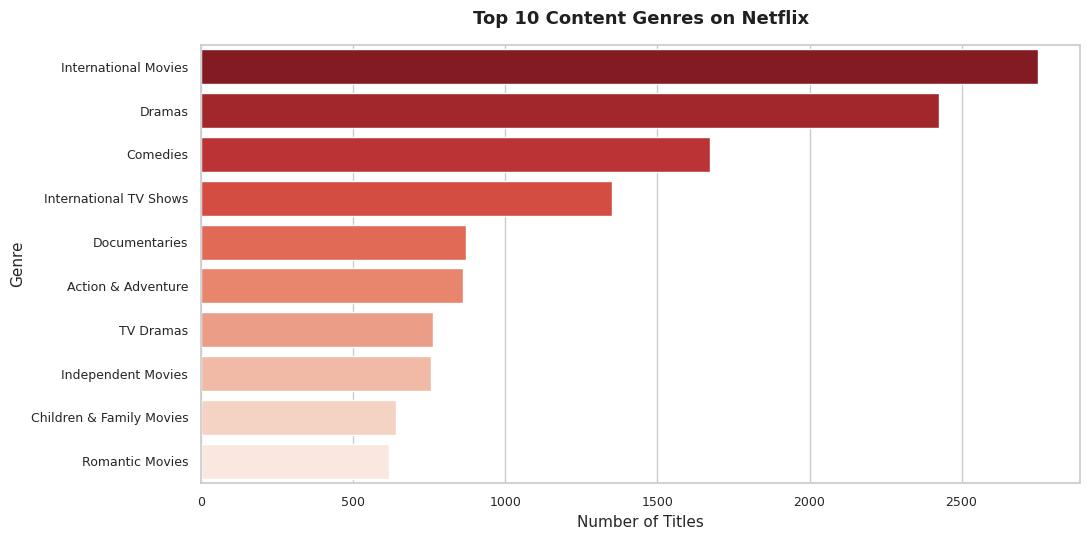

In [135]:
plt.figure(figsize=(11, 5.5))
all_genres = df_clean['listed_in'].str.split(', ').explode()
genre_counts = all_genres.value_counts().head(10)

sns.barplot(x=genre_counts.values, y=genre_counts.index, hue=genre_counts.index, palette='Reds_r', legend=False)
plt.title('Top 10 Content Genres on Netflix', pad=15, fontweight='bold', color=netflix_dark)
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

### 2. Line Chart: Netflix Content Additions Over Time
Plotting the trajectory of catalog size growth from 2008 to 2021, separated by Movie vs. TV Show types.

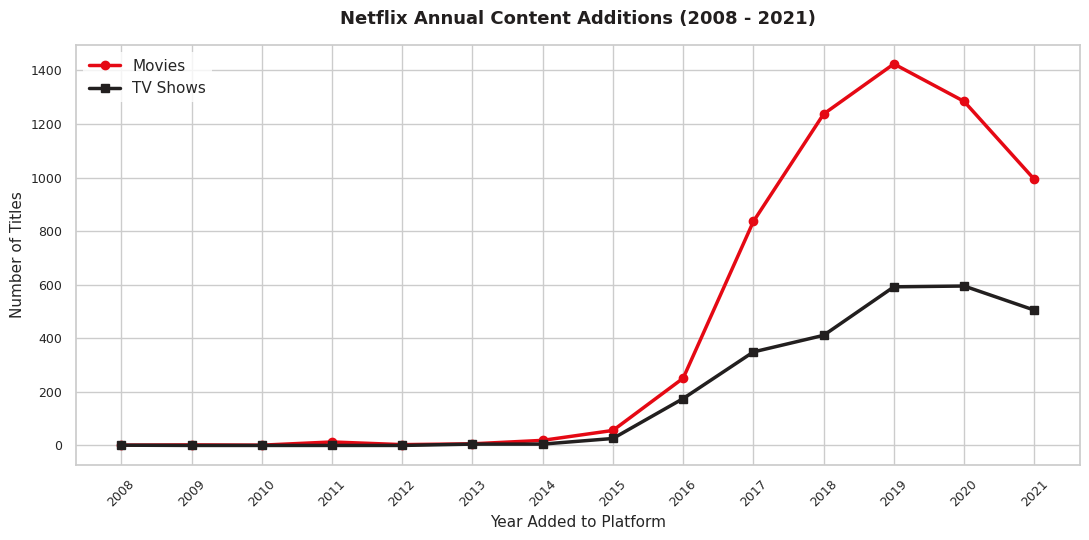

In [136]:
plt.figure(figsize=(11, 5.5))
yearly_additions = df_clean.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly_additions = yearly_additions[yearly_additions.index >= 2008]

plt.plot(yearly_additions.index, yearly_additions['Movie'], marker='o', color=netflix_red, linewidth=2.5, label='Movies')
plt.plot(yearly_additions.index, yearly_additions['TV Show'], marker='s', color=netflix_dark, linewidth=2.5, label='TV Shows')
plt.title('Netflix Annual Content Additions (2008 - 2021)', pad=15, fontweight='bold', color=netflix_dark)
plt.xlabel('Year Added to Platform')
plt.ylabel('Number of Titles')
plt.xticks(yearly_additions.index, rotation=45)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

### 3. Histogram: Distribution of Movie Durations
Investigating runtime spreads in minutes for movies, showing mean and median values.

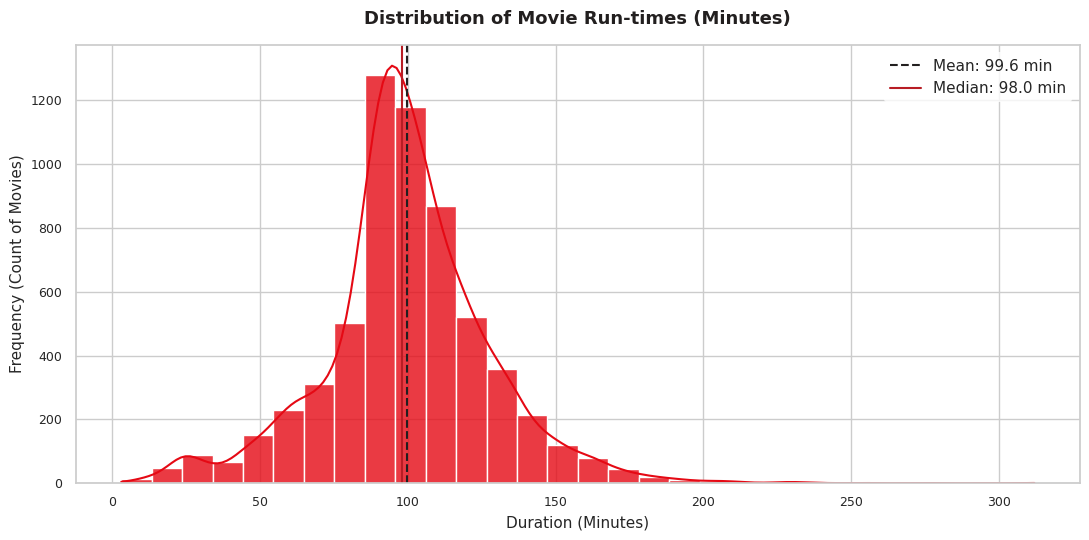

In [137]:
plt.figure(figsize=(11, 5.5))
movies_df = df_clean[df_clean['type'] == 'Movie']

sns.histplot(movies_df['duration_value'], bins=30, kde=True, color=netflix_red, edgecolor='white', alpha=0.8)
plt.title('Distribution of Movie Run-times (Minutes)', pad=15, fontweight='bold', color=netflix_dark)
plt.xlabel('Duration (Minutes)')
plt.ylabel('Frequency (Count of Movies)')

mean_val = movies_df['duration_value'].mean()
median_val = movies_df['duration_value'].median()
plt.axvline(mean_val, color=netflix_dark, linestyle='--', linewidth=1.5, label=f"Mean: {mean_val:.1f} min")
plt.axvline(median_val, color='#B81D24', linestyle='-', linewidth=1.5, label=f"Median: {median_val:.1f} min")
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

### 4. Scatter Plot: Release Year vs. Movie Duration
Checking if movie runtimes have contracted or expanded in recent decades (filtering to releases since 1980 for visibility).

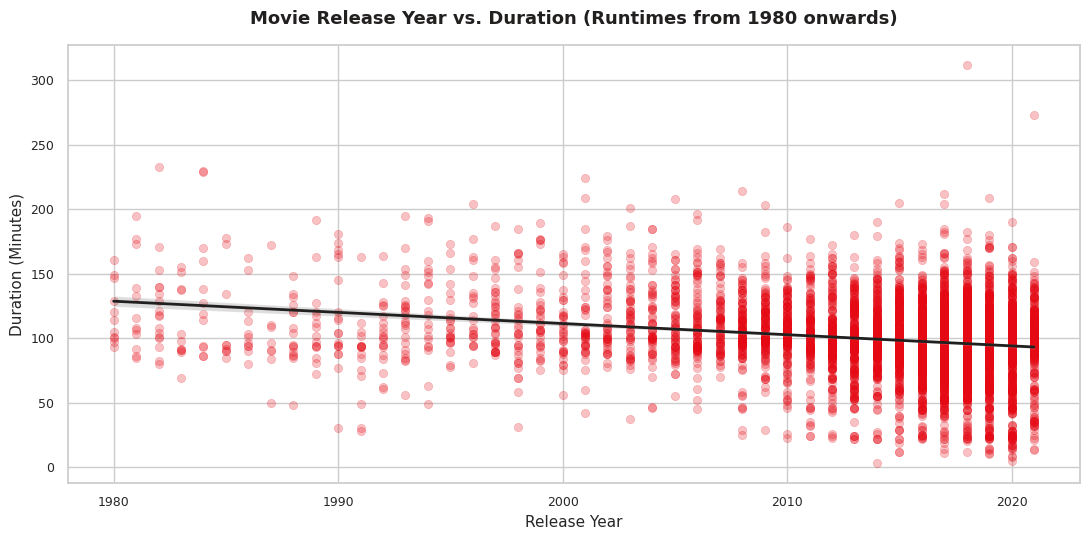

In [138]:
plt.figure(figsize=(11, 5.5))
movies_recent = movies_df[movies_df['release_year'] >= 1980]

sns.scatterplot(data=movies_recent, x='release_year', y='duration_value', alpha=0.25, color=netflix_red, edgecolor=None)
sns.regplot(data=movies_recent, x='release_year', y='duration_value', scatter=False, color=netflix_dark, line_kws={'linewidth': 2})

plt.title('Movie Release Year vs. Duration (Runtimes from 1980 onwards)', pad=15, fontweight='bold', color=netflix_dark)
plt.xlabel('Release Year')
plt.ylabel('Duration (Minutes)')
plt.tight_layout()
plt.show()

### 5. Pie Chart: Classification Rating Distribution
Displaying target audience segmentation across Netflix's catalog.

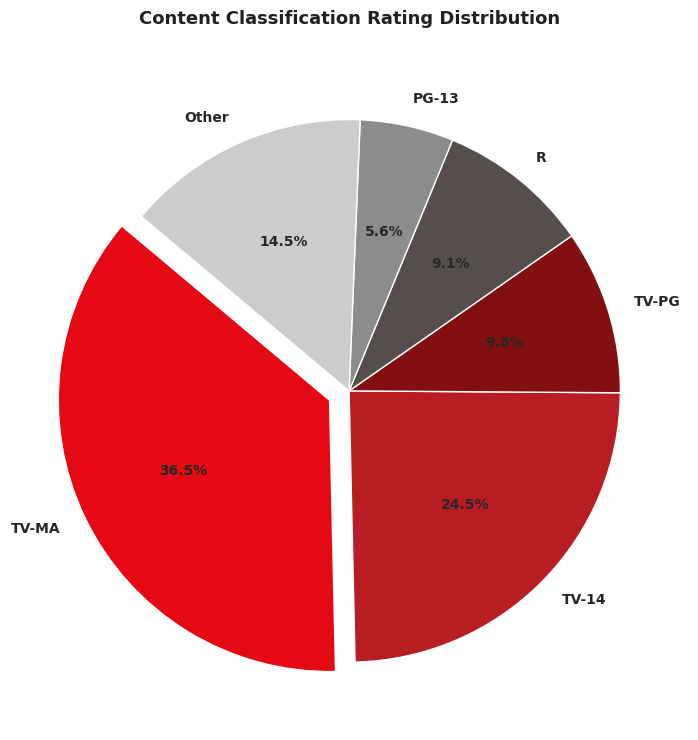

In [139]:
plt.figure(figsize=(7.5, 7.5))
rating_counts = df_clean['rating'].value_counts()
top_ratings = rating_counts.head(5).copy()
top_ratings['Other'] = rating_counts.iloc[5:].sum()

pie_colors = [netflix_red, '#B81D24', '#831010', '#564D4D', '#8C8C8C', '#CCCCCC']
explode = [0.08 if i == 0 else 0 for i in range(len(top_ratings))] # Explode TV-MA

plt.pie(
    top_ratings.values,
    labels=top_ratings.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=pie_colors,
    explode=explode,
    textprops={'fontsize': 10, 'weight': 'bold'}
)
plt.title('Content Classification Rating Distribution', pad=20, fontweight='bold', color=netflix_dark)
plt.tight_layout()
plt.show()

### 6. Heatmap: Correlation Matrix of Numeric Movie Features
Analyzing correlations between a movie's release year, the year it was uploaded to Netflix, and its duration.

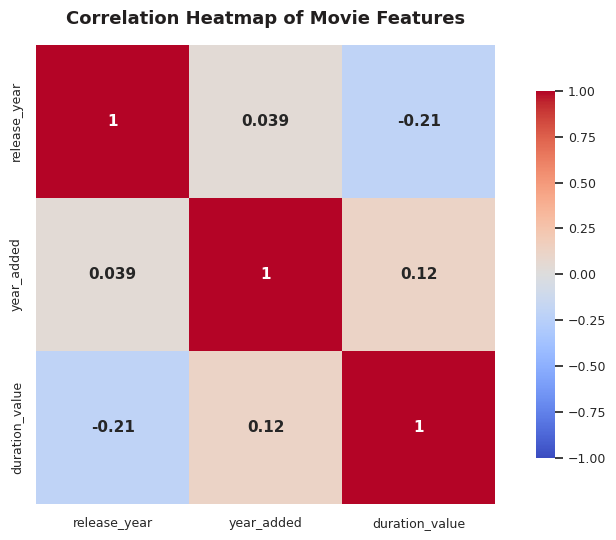

In [140]:
plt.figure(figsize=(8.5, 5.5))
movies_numeric = movies_df[['release_year', 'year_added', 'duration_value']].dropna()
corr_matrix = movies_numeric.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 11, 'weight': 'bold'}
)
plt.title('Correlation Heatmap of Movie Features', pad=15, fontweight='bold', color=netflix_dark)
plt.tight_layout()
plt.show()

## Insights Report

1. **Netflix Has More Movies Than TV Shows** – Most of the content on Netflix is made up of **movies (69.69%)**, while **TV shows account for 30.31%**. This shows that Netflix focuses more on offering a large collection of movies, while still keeping a good number of TV shows for users who enjoy longer series.

2. **Most Content is for Mature Audiences** – The largest content rating on Netflix is **TV-MA (36.5%)**, followed by **TV-14 (24.5%)**. Together, these make up more than **60%** of the platform's content. This means Netflix mainly creates and acquires content for teenagers and adults rather than young children.

3. **Movies Have Become Shorter Over Time** – The data shows that newer movies are generally shorter than older ones. Most movies released after **2010** are around **90–100 minutes** long, while older movies have a wider range of runtimes. This suggests that movie lengths have become shorter over the years.

4. **Netflix Added the Most Content in 2019** – Netflix added the highest number of movies and TV shows in **2019**. After that, the number of new additions decreased, likely because the **COVID-19 pandemic** affected film and TV production. Netflix also started focusing more on producing its own original content instead of adding many licensed titles.

5. **Netflix Includes Both New and Old Movies** – The data shows almost **no relationship** between a movie's release year and the year it was added to Netflix. This means Netflix does not only add newly released movies; it also regularly adds older movies and classic titles to give users a wider variety of content.
